<a href="https://colab.research.google.com/github/gpicciuca/ai_engineering_master/blob/main/module11_explainable_ai/Project_Interpretation_of_a_NN_for_normative_compliance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Interpretation of a neural network for normative compliance
Course: AI Engineering @ Profession.AI <br>
Module: Explainable AI <br>
Student: Giuseppe Picciuca <br> <br>

The aim of this project is to investigate the explainability of a pretrained CNN Model in classification tasks, to determine whether the generated predictions can be trusted and are based on concrete and reliable features.<br>
Below we'll run an investigation on DenseNet pretrained on ImageNet-1K and fine-tuned on MNIST, and analyze saliency maps using different techniques (Grad-CAM, LIME, SHAP, Integrated Gradients, Occlusion Maps) to understand how it's reasoning, where it fails and where it excels.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import densenet121, DenseNet121_Weights
from torchvision.datasets import MNIST
import torchvision.transforms as T
import torchvision.transforms.v2 as T2

from torch.utils.data import DataLoader

from tqdm import tqdm
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Model preparation
We'll be using a pre-trained classification model from the torchvision hub, e.g. DenseNet.

In [ ]:
model = densenet121(weights=DenseNet121_Weights.DEFAULT)
model

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

# Dataset preparation
We'll need to fine-tune DenseNet on our dataset of choice in order to run a proper analysis. For this, we'll be using the MNIST dataset.

In [ ]:
# Check which image transformations were used in the pretrained model
DenseNet121_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

MNIST images have only 1 channel, but DenseNet was trained on RGB images so we need to properly transform the images in the expected format.

In [ ]:
image_mean = np.array([0.485, 0.456, 0.406])
image_std = np.array([0.229, 0.224, 0.225])

mnist_transform = T.Compose([
    T2.RGB(), # Transform grayscale to RGB to be compatible with DenseNet
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean=image_mean, std=image_std),
])

In [ ]:
train_dataset = MNIST(root='./data', train=True, download=True, transform=mnist_transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=mnist_transform)

In [ ]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               RGB()
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485 0.456 0.406], std=[0.229 0.224 0.225])
           )

In [ ]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               RGB()
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485 0.456 0.406], std=[0.229 0.224 0.225])
           )

# Model fine-tuning
We need to briefly retrain DenseNet on the chosen dataset. The pretrained model from torchvision was trained on ImageNet-1K so, in order to have the correct classification output, the classification head needs to be replaced and retrained.

In [ ]:
NUM_EPOCHS = 5
BATCH_SIZE = 32
USE_PRETRAINED = True

In [ ]:
# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# Overwrite classification head
model.classifier = nn.Linear(1024, len(test_dataset.classes))

Setup the training loop with all required components: data loader, optimizer, loss function. We'll be training the model for just 5 epochs since the MNIST has very few classes, so it will be fast to converge:

In [ ]:
if not USE_PRETRAINED:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.00004)
    criterion = nn.CrossEntropyLoss()

    model.to(device)

    for epoch in range(NUM_EPOCHS):
        model.train()

        train_loss = 0
        train_acc = 0

        for i, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += (outputs.argmax(dim=1) == labels).sum().item() / len(labels)

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        print(f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")

    torch.save(model.state_dict(), "densenet_mnist.pt")

Epoch 1: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1875/1875 [05:46<00:00,  5.41it/s]


Train loss: 0.3748, Train acc: 0.9006


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1875/1875 [05:33<00:00,  5.62it/s]


Train loss: 0.1867, Train acc: 0.9425


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1875/1875 [05:37<00:00,  5.55it/s]


Train loss: 0.1587, Train acc: 0.9505


Epoch 4: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1875/1875 [05:42<00:00,  5.48it/s]


Train loss: 0.1456, Train acc: 0.9545


Epoch 5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1875/1875 [05:45<00:00,  5.42it/s]


Train loss: 0.1397, Train acc: 0.9551


In [ ]:
# Load model from saved checkpoint
model.load_state_dict(torch.load("densenet_mnist.pt"))

/home/shini/deeplearning/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:816: UserWarning: Can't initialize amdsmi - Error code: 34
  warnings.warn(f"Can't initialize amdsmi - Error code: {e.err_code}")


<All keys matched successfully>

# Model performance on testset
Before diving into the explainability analysis, it might be useful to check how the model currently performs and which samples are classified correctly (and which ones are not). This will also be helpful later so we can pick some samples to study:

In [ ]:
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.CrossEntropyLoss()

model.eval()
model.to(device)

test_loss = 0
test_acc = 0

predictions = []

with torch.no_grad():
    for i, (images, labels) in enumerate(tqdm(test_loader, desc=f"Evaluating")):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        y_preds = outputs.argmax(dim=1)
        predictions.extend(y_preds.cpu().detach())

        test_loss += loss.item()
        test_acc += (y_preds == labels).sum().item() / len(labels)

    test_loss /= len(test_loader)
    test_acc /= len(test_loader)

print(f"\nTest loss: {test_loss:.4f}\nTest acc: {test_acc:.4f}")

Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:59<00:00,  5.30it/s]


Test loss: 0.1148
Test acc: 0.9618


In [ ]:
# Convert list of predicted labels into a tensor
y_preds = torch.tensor(predictions)

# Generate a prediction mask
y_preds_correct_mask = (y_preds == test_dataset.targets)
y_preds_incorrect_mask = ~y_preds_correct_mask

Plot the confusion matrix to see which classes are most difficult to predict correctly:

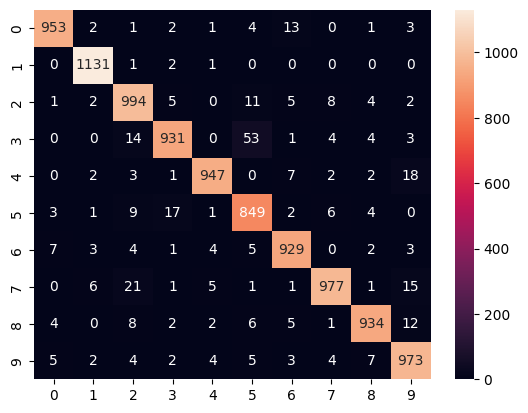

In [ ]:
sns.heatmap(confusion_matrix(test_dataset.targets, y_preds), annot=True, fmt='g');

On a first glance, it looks like the following pairs are most commonly confused:
- 3 and 5
- 2 and 3
- 4 and 9
- 7 and 9
- 2 and 7
- and some other...

Let's proceed with some detailed analysis of the decisions taken by our model.

# Saliency map helpers
Let's first prepare some helper methods to easily create saliency maps and keep the code clean and readable.


In [ ]:
!pip install --upgrade grad-cam lime shap captum

## Grad-CAM

In [ ]:
from captum.attr import LayerGradCam

def get_gradcam_map(model, layer, image, target_label):
    layer_gradcam = LayerGradCam(model, layer)
    gradcam_attributions = layer_gradcam.attribute(image.unsqueeze(0).to(device), target=target_label)
    gradcam_map = gradcam_attributions.squeeze().detach().cpu().numpy()
    return gradcam_map

/home/shini/deeplearning/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


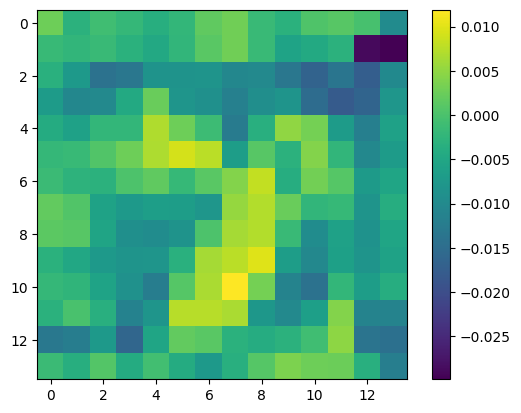

In [ ]:
# Test map generation
plt.imshow(get_gradcam_map(model, model.features.denseblock3.denselayer16, test_dataset[0][0], test_dataset[0][1]))
plt.colorbar()

## LIME

In [ ]:
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import mark_boundaries

def denormalize_image_tensor(image: torch.Tensor):
    img = image.cpu().detach().clone()
    for channel_idx in range(img.shape[0]):
        img[channel_idx] = img[channel_idx] * image_mean[channel_idx] + image_std[channel_idx]
    img = img.numpy().transpose(1, 2, 0)
    img  = (img * 255.0).astype(np.uint8)
    return img

def model_predict_wrapper(model, batch):
    image_batch = batch.transpose(0, 3, 1, 2)
    image_batch = torch.from_numpy(image_batch.astype(np.float32))
    image_batch = T.Normalize(mean=image_mean, std=image_std)(image_batch)

    with torch.no_grad():
        image_batch = image_batch.to(device)
        outputs = model(image_batch)
        return F.softmax(outputs, dim=1).cpu().detach().numpy()

def get_lime_map(model, image, target_label, num_features):
    explainer = LimeImageExplainer()
    denormalized_image = denormalize_image_tensor(image)

    explanation  = explainer.explain_instance(
        denormalized_image,
        lambda x: model_predict_wrapper(model, x),
        top_labels=10,
        labels=[target_label],
        batch_size=BATCH_SIZE
    )

    img, mask = explanation.get_image_and_mask(
        label=target_label,
        positive_only=True,
        num_features=num_features,
        hide_rest=False
    )

    boundary_map = mark_boundaries(img / 255.0, mask)
    boundary_map = boundary_map.transpose(2, 0, 1)
    return np.mean(np.abs(boundary_map), axis=0)

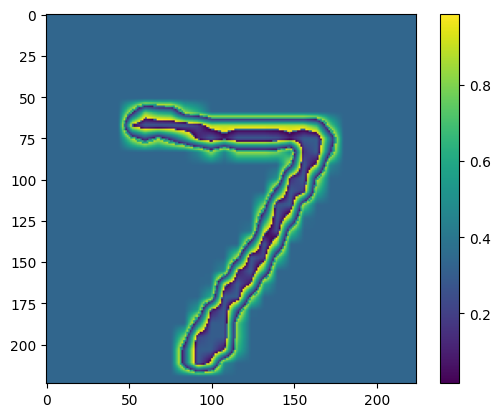

In [ ]:
# Test map generation
boundaries = get_lime_map(model, test_dataset[0][0], test_dataset[0][1], len(test_dataset.classes))
plt.imshow(boundaries)
plt.colorbar()

## SHAP

In [ ]:
import shap

def get_shap_map(model, image, background_data):
    explainer = shap.GradientExplainer(model, background_data.to(device))
    shap_values, indexes = explainer.shap_values(image.unsqueeze(0).to(device), ranked_outputs=1)
    return np.mean(np.abs(shap_values[0]), axis=0)

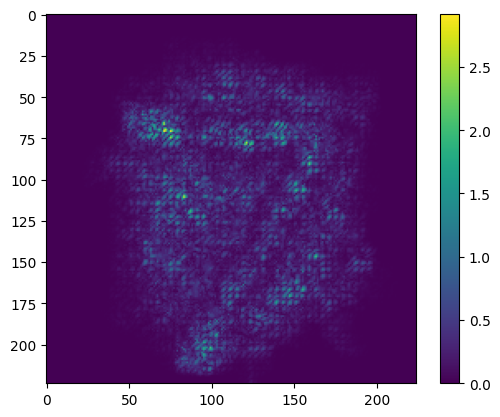

In [ ]:
# Test map generation
shap_map = get_shap_map(
    model,
    test_dataset[0][0],
    torch.from_numpy(np.array([test_dataset[i][0] for i in range(50)]))
)
plt.imshow(shap_map)
plt.colorbar()

## Integrated Gradients

In [ ]:
from captum.attr import IntegratedGradients

def get_ig_map(model, image, target_label):
    explainer = IntegratedGradients(model)
    attributions, approx_error = explainer.attribute(image.unsqueeze(0).to(device), target=target_label, return_convergence_delta=True)
    attr_map = attributions.squeeze().detach().cpu().numpy()
    return np.mean(np.abs(attr_map), axis=0)

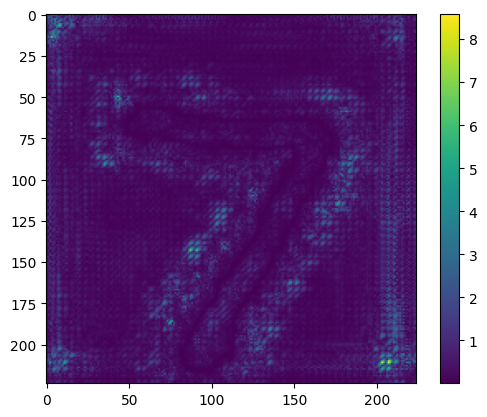

In [ ]:
# Test map generation
ig_map = get_ig_map(model, test_dataset[0][0], test_dataset[0][1])
plt.imshow(ig_map)
plt.colorbar()

## Occlusion Maps

In [ ]:
from captum.attr import Occlusion

def get_occlusion_map(model, image, target_label):
    explainer = Occlusion(model)
    attributions = explainer.attribute(
        image.unsqueeze(0).to(device),
        target=target_label,
        strides=(3, 10, 10),
        sliding_window_shapes=(3, 11, 11)
    )
    attr_map = attributions.squeeze().detach().cpu().numpy()
    return np.mean(np.abs(attr_map), axis=0)

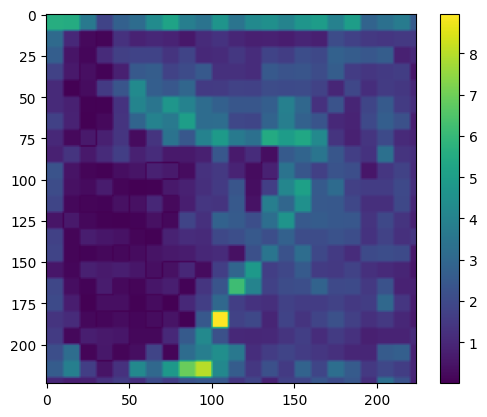

In [ ]:
# Test map generation
occlusion_map = get_occlusion_map(model, test_dataset[0][0], test_dataset[0][1])
plt.imshow(occlusion_map)
plt.colorbar()

# Analysis of saliency maps
Now that we have all needed helper methods, we can move on and analyze some of the misclassified samples.

In [ ]:
correct_sample_indices = np.argwhere(y_preds_correct_mask.numpy()).flatten()
incorrect_sample_indices = np.argwhere(y_preds_incorrect_mask.numpy()).flatten()
print("Total correct classifications: ", len(correct_sample_indices))
print("Total incorrect classifications: ", len(incorrect_sample_indices))

Total correct classifications:  9618
Total incorrect classifications:  382


And to further simplify things, we'll create a list of true labels for the misclassified samples. This will facilitate pinpointing samples for certain classes that we'd like to inspect:

In [ ]:
true_labels_for_incorrect_samples = []

for index in incorrect_sample_indices:
    true_labels_for_incorrect_samples.append(test_dataset.targets[index])

true_labels_for_incorrect_samples = np.array(true_labels_for_incorrect_samples)
true_labels_for_incorrect_samples

array([9, 3, 9, 3, 2, 8, 4, 2, 0, 5, 6, 4, 3, 7, 9, 0, 3, 8, 0, 8, 3, 8,
       9, 0, 7, 6, 2, 7, 7, 4, 1, 0, 4, 8, 3, 8, 5, 4, 9, 4, 3, 8, 5, 4,
       6, 2, 6, 7, 9, 3, 9, 3, 4, 3, 7, 7, 7, 2, 5, 9, 8, 7, 5, 3, 8, 3,
       5, 2, 4, 0, 6, 4, 3, 7, 7, 8, 3, 0, 9, 7, 6, 3, 4, 3, 7, 5, 3, 3,
       2, 0, 8, 2, 3, 9, 3, 7, 6, 5, 7, 0, 5, 4, 7, 4, 3, 3, 3, 4, 6, 4,
       5, 1, 7, 8, 5, 9, 2, 3, 0, 0, 5, 5, 9, 6, 2, 8, 5, 3, 3, 7, 5, 7,
       2, 6, 7, 2, 4, 0, 8, 3, 4, 9, 6, 9, 6, 9, 1, 5, 2, 3, 3, 4, 8, 7,
       7, 5, 2, 0, 7, 4, 0, 6, 7, 3, 4, 3, 5, 7, 2, 9, 7, 3, 0, 8, 5, 7,
       3, 6, 3, 7, 5, 4, 2, 7, 2, 9, 9, 9, 2, 3, 7, 4, 9, 3, 0, 8, 8, 8,
       5, 2, 9, 8, 4, 4, 9, 3, 9, 5, 2, 4, 3, 8, 5, 9, 8, 3, 6, 7, 6, 0,
       2, 6, 3, 7, 3, 3, 6, 8, 3, 3, 2, 6, 9, 4, 3, 4, 7, 2, 8, 7, 5, 3,
       2, 8, 3, 3, 0, 8, 5, 8, 7, 8, 2, 1, 7, 3, 7, 7, 5, 7, 5, 6, 8, 3,
       3, 4, 7, 6, 3, 5, 3, 5, 3, 5, 5, 5, 3, 5, 3, 3, 9, 9, 3, 0, 9, 0,
       2, 8, 0, 9, 9, 7, 8, 7, 6, 6, 8, 9, 9, 8, 0,

Given the confusion matrix from earlier, we found that the worst class had 53 misclassified samples (class 3 misclassified as 5). So let's take a look at class 3 and see why it's struggling so much with it.

In [ ]:
class_3_correct_indices = np.argwhere(y_preds[y_preds_correct_mask] == 3).flatten()
class_3_correct_samples = correct_sample_indices[class_3_correct_indices]
print("Number of correct class 3 samples: ", len(class_3_correct_samples))

class_3_incorrect_indices = np.argwhere(true_labels_for_incorrect_samples == 3).flatten()
class_3_incorrect_samples = incorrect_sample_indices[class_3_incorrect_indices]

print("Number of incorrect class 3 samples: ", len(class_3_incorrect_samples))

Number of correct class 3 samples:  931
Number of incorrect class 3 samples:  79


Now that we have everything, we can define a helper method to plot those samples along their saliency maps in a nice grid plot:

In [ ]:
import torchvision.transforms.functional as TF

def plot_saliency_maps(dataset, sample_indices, rows, cols, title_color="green"):
    plt.figure(figsize=(cols + 1, rows + 1))

    shap_background_data = torch.from_numpy(np.array([dataset[i][0] for i in range(50)]))

    for i, sample_index in enumerate(sample_indices[:rows]):
        image, target_label = dataset[sample_index]
        predicted_label = y_preds[sample_index]

        plt.subplot(rows, cols, i * cols + 1)
        plt.title(int(y_preds[sample_index]), color=title_color)
        plt.imshow(TF.rgb_to_grayscale(image).squeeze(), cmap="gray")
        plt.axis("off")

        plt.subplot(rows, cols, i * cols + 2)
        plt.title("Grad-CAM")
        plt.imshow(get_gradcam_map(model, model.features.denseblock3.denselayer16, image, target_label))
        plt.axis("off")

        plt.subplot(rows, cols, i * cols + 3)
        plt.title("LIME")
        plt.imshow(get_lime_map(model, image, target_label, len(dataset.classes)))
        plt.axis("off")

        plt.subplot(rows, cols, i * cols + 4)
        plt.title("SHAP")
        plt.imshow(get_shap_map(model, image, shap_background_data))
        plt.axis("off")

        plt.subplot(rows, cols, i * cols + 5)
        plt.title("IG")
        plt.imshow(get_ig_map(model, image, target_label))
        plt.axis("off")

        plt.subplot(rows, cols, i * cols + 6)
        plt.title("Occlusion")
        plt.imshow(get_occlusion_map(model, image, target_label))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Finally, let's run the plotting and visualize some samples with their saliency maps. This will help us understand why it's misclassifying some samples.

## Plotting of saliency maps of correct class 3 samples

In [ ]:
COL_COUNT = 6 # 1 image + 5 saliency maps
ROW_COUNT = min(30, len(class_3_correct_samples))

print(f"Rows: {ROW_COUNT}, Cols: {COL_COUNT}")

Rows: 30, Cols: 6


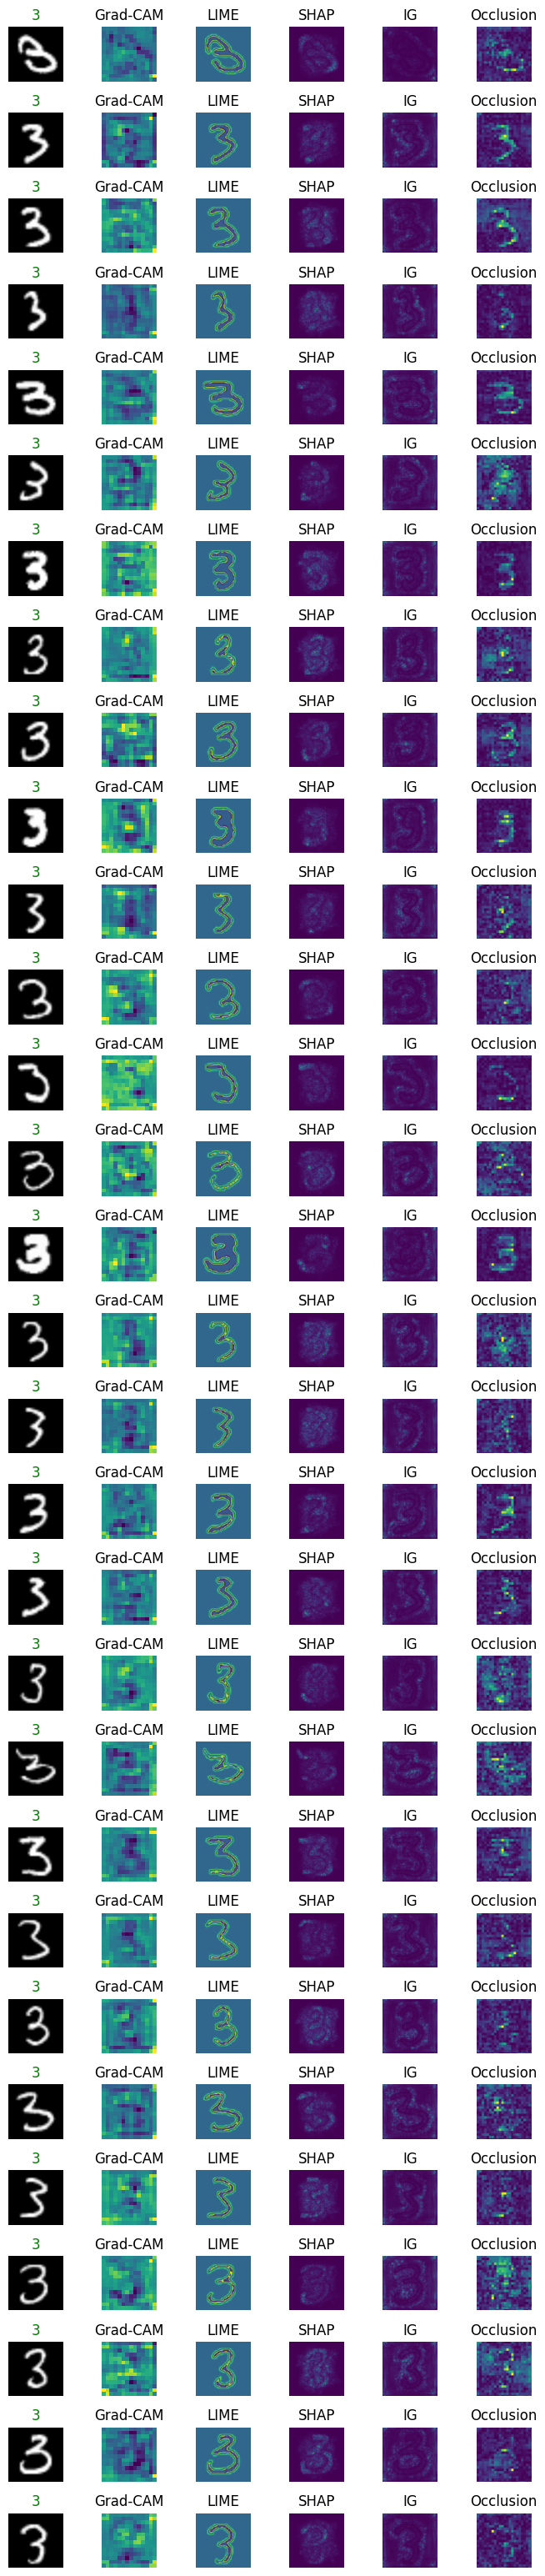

In [ ]:
plot_saliency_maps(test_dataset, class_3_correct_samples, ROW_COUNT, COL_COUNT)

## Plotting of saliency maps of incorrect class 3 samples

In [ ]:
COL_COUNT = 6 # 1 image + 5 saliency maps
ROW_COUNT = min(50, len(class_3_incorrect_samples))

print(f"Rows: {ROW_COUNT}, Cols: {COL_COUNT}")

Rows: 50, Cols: 6


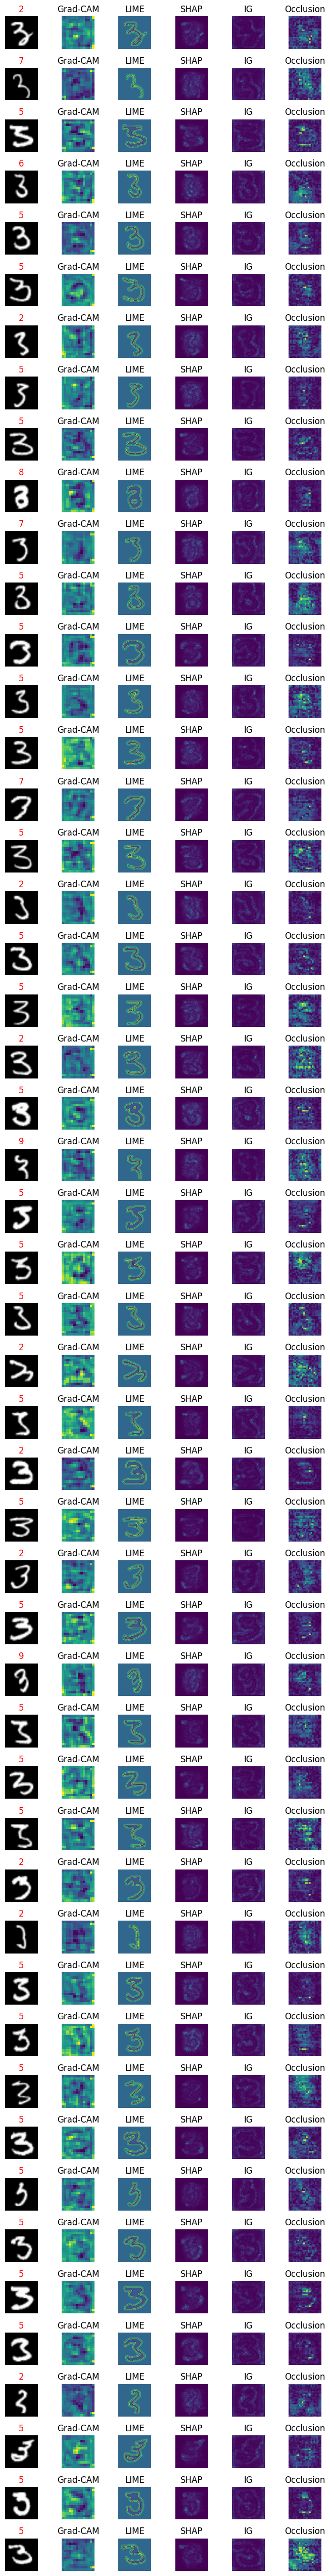

In [ ]:
plot_saliency_maps(test_dataset, class_3_incorrect_samples, ROW_COUNT, COL_COUNT, title_color="red")

# Final report

## Dataset description

We've used the MNIST Dataset for evaluating DenseNet, a deep convolutional neural network pre-trained on ImageNet 1K, retrained on a 10-class digits dataset such as MNIST. <br><br>
MNIST contains hand-written samples of digits from 1 to 9, in small 28x28 px images in grayscale, downloaded from the torchvision hub. 60000 samples were used for the training set, 10000 for the testset. <br><br>
Original source: http://yann.lecun.com/exdb/mnist/

## Saliency maps analysis

For the generation of saliency maps, we've used different techniques:
- Grad-CAM
- LIME
- SHAP
- Integrated Gradients
- Occlusion Maps

All of which provide valuable insights in the decisions the model has made during classification. <br>


The 2 grid-plots above show saliency maps for correctly classified samples of class 3 as well as the maps for incorrectly classified ones for class 3. <br><br>
All maps use the same colorbar, where brighter colors point to places with higher importance, compared to darker colors which have less importance during the classification step. <br><br>
Knowing how to interpret the brightness of the colors, we can immediately spot one common pattern in all saliency maps (except SHAP) that we've generated: They all highlight the outer contour of the digits, with the actual internals of the digit left with darker colors.<br>
This alone already tells us that the model is focussing more on the overall shape (edges, contours) seen from the outside. <br>
SHAP seems to highlight this pattern the other way around: Brighter spots can be seen within the digits, and less so on the outside. <br><br>
LIME is confirming this theory: A very bright contour is all around the digit from the outside, leaving the inside with "less importance".
<br><br>
Overall, the model is doing well in detecting the boundary of the "object" it's looking at, but if we take a look at Grad-CAM and Occlusion maps, we see that the brighter spots are mostly outside of the digit itself, indicating that the model is relying on certain pixel-positions only to classify if a digit is a 3 or a 5. Infact, 3 and 5 share the same bottom half of the symbol, so if the model relies on pixels from the lower half, it will misclassify 3 for 5 and viceversa.
<br><br>
Moreover, the occlusion maps show another important flaw: The "attention pixels", or rather, the bright pixels that the model relies on to make its prediction, are not always of the same shape as the digit itself. Infact, many occlusion maps show strangely formed clusters/clouds of bright pixels, while in very few cases we see a nicely shaped and recognizable digit.

## Proposing an explainable system

DenseNet is doing an excellent job at detecting shapes and boundaries, as we've deduced from all the saliency maps. However, the pixels to which it pays most attention to are not always reliable.
<br><br>
There are several ways how we can design a more reliable model:
- Using occlusion maps over the input image, so the model see's only the object it needs to classify and not the background or other irrelevant features
- Per-pixel loss function that uses saliency maps to guide the backpropagation of certain layers (combined objective: classification + layer activations).
- Segmentation mask where the model learns to segment objects and then uses the generated mask at some point in its hidden layers
<br>
The above points are ranked by difficulty. The simplest approach is probably to just provide occluded images to the model, but this would lead to inputs similar to what we already have in MNIST. MNIST contains 28x28 px images with all 0 except for the digit pixels, so the background is already "occluded" and yet, the model still does not learn to pay more attention to the actual pixels than the surroundings.
<br><br>
In the approach 2 we'd need to retrieve the output of intermediate layers and calculate a loss function on their output. For this to work, we'd require masked intermediated outputs for whichever layer we choose. This should, at least in theory, help guide the activation maps more towards the desired pixels instead of letting the model decide on its own.
<br><br>
In approach 3 we'd need to train essentially 2 models: One that learns to segment objects (much like YOLO does), and another one (e.g. DenseNet) that learns how to use the segmentation mask to guide its activation maps which is then forwarded to the downstream layers for classification.
<br><br>
Approach 2 and 3 are mere ideas which may, or may not, work at all. Assuming that there is a chance they could work, we'd need to decide at which level to plug those techniques into. For this, we can use LayerGradCam to visualize the activation maps of intermediate layers. Below is a plot of the first and last layer of each block:

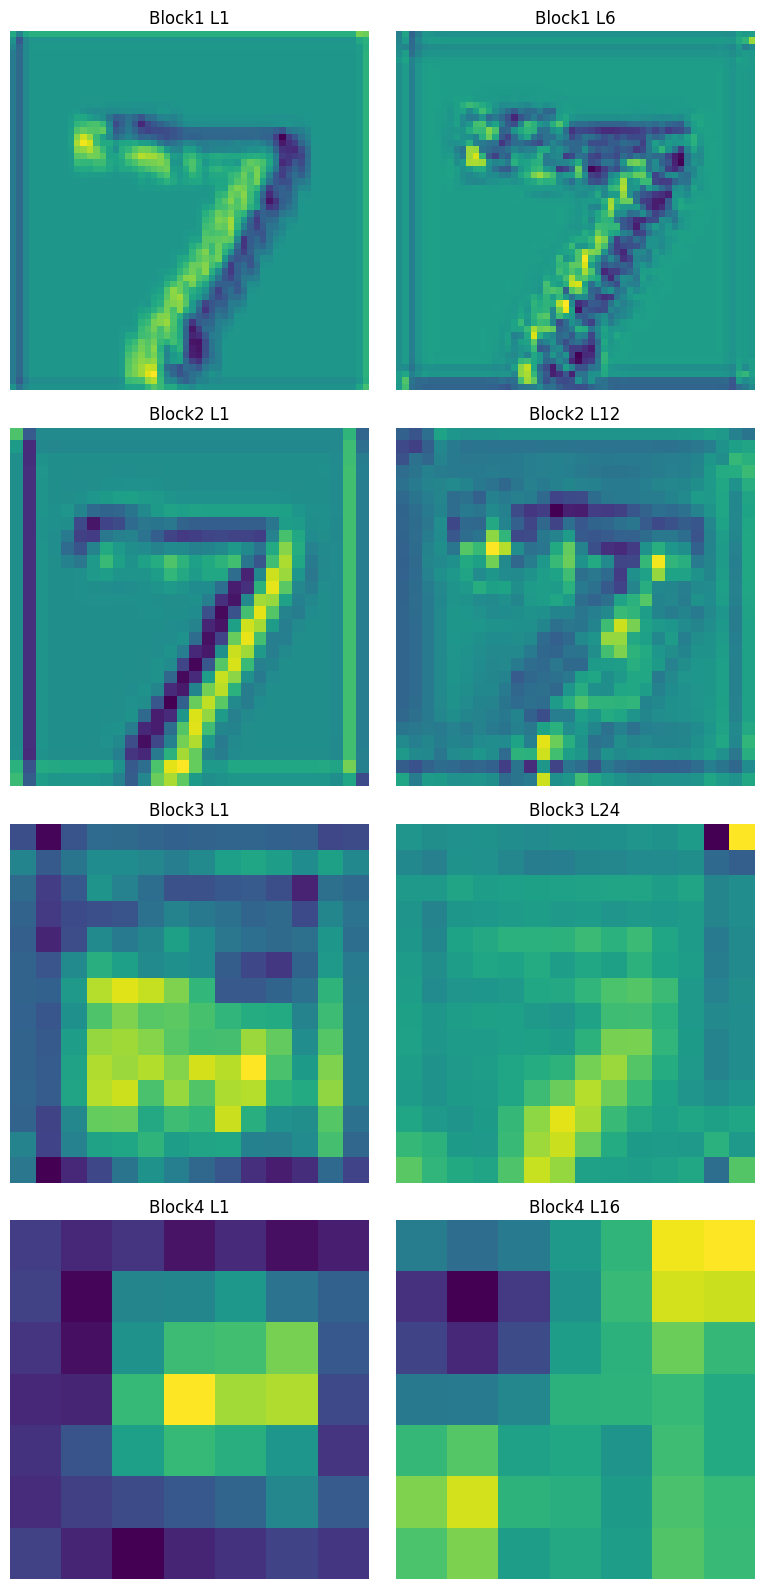

In [ ]:
plt.figure(figsize=(8, 16))

plt.subplot(4, 2, 1)
plt.title("Block1 L1")
plt.imshow(get_gradcam_map(model, model.features.denseblock1.denselayer1, test_dataset[0][0], test_dataset[0][1]))
plt.axis("off")

plt.subplot(4, 2, 2)
plt.title("Block1 L6")
plt.imshow(get_gradcam_map(model, model.features.denseblock1.denselayer6, test_dataset[0][0], test_dataset[0][1]))
plt.axis("off")

plt.subplot(4, 2, 3)
plt.title("Block2 L1")
plt.imshow(get_gradcam_map(model, model.features.denseblock2.denselayer1, test_dataset[0][0], test_dataset[0][1]))
plt.axis("off")

plt.subplot(4, 2, 4)
plt.title("Block2 L12")
plt.imshow(get_gradcam_map(model, model.features.denseblock2.denselayer12, test_dataset[0][0], test_dataset[0][1]))
plt.axis("off")

plt.subplot(4, 2, 5)
plt.title("Block3 L1")
plt.imshow(get_gradcam_map(model, model.features.denseblock3.denselayer1, test_dataset[0][0], test_dataset[0][1]))
plt.axis("off")

plt.subplot(4, 2, 6)
plt.title("Block3 L24")
plt.imshow(get_gradcam_map(model, model.features.denseblock3.denselayer24, test_dataset[0][0], test_dataset[0][1]))
plt.axis("off")

plt.subplot(4, 2, 7)
plt.title("Block4 L1")
plt.imshow(get_gradcam_map(model, model.features.denseblock4.denselayer1, test_dataset[0][0], test_dataset[0][1]))
plt.axis("off")

plt.subplot(4, 2, 8)
plt.title("Block4 L16")
plt.imshow(get_gradcam_map(model, model.features.denseblock4.denselayer16, test_dataset[0][0], test_dataset[0][1]))
plt.axis("off")

plt.tight_layout()
plt.show()

As can be seen in the plots above, starting at Block3 the saliency map kind of becomes a big blob of pixels, which further scrumbles in Block 4. At Layer12 of Block2 we already see how the important pixels started to fade away compared to the Layer1 of Block2. <br>
Therefore, a good entrypoint for our masked activation guidance (approach 2 and 3) could be the input to Block2, with the final output of Block2 being the one we'd run the loss function on.
<br>
So we'd run 2 Models in parallel, and then merge them at Block2 (either by concatenating, summing, calculating the mean value, or by doing some bitmask operation to disable irrelevant pixels).